In [1]:
import os
import glob
from ruamel.yaml import YAML

def atualizar_sequencias():
    # Inicializa o parser YAML configurado para preservar os comentários
    yaml = YAML()
    yaml.preserve_quotes = True
    
    # Caminho onde os arquivos YAML estão salvos
    diretorio_params = '/home/aki/Desktop/GitHub/Python-VO/params/'
    
    # Dicionário que mapeia o início do nome do arquivo para o valor de 'sequence' desejado.
    # Altere os valores abaixo conforme os nomes reais das suas sequências.
    mapa_sequencias = {
        'cusco': 'cusco_dataset_2',
        'kaist': 'urban30', 
        'kitti': '00'        
    }
    
    # Busca todos os arquivos .yaml no diretório
    arquivos_yaml = glob.glob(os.path.join(diretorio_params, '*.yaml'))
    
    if not arquivos_yaml:
        print(f"Nenhum arquivo YAML encontrado em: {diretorio_params}")
        return

    for caminho_arquivo in arquivos_yaml:
        nome_arquivo = os.path.basename(caminho_arquivo)
        
        # Pega a primeira palavra do nome do arquivo (antes do primeiro '_')
        # Ex: de 'cusco_orb_brutematch.yaml' extrai 'cusco'
        prefixo_dataset = nome_arquivo.split('_')[0].lower()
        
        if prefixo_dataset in mapa_sequencias:
            nova_sequencia = mapa_sequencias[prefixo_dataset]
            
            # 1. Abre e lê o conteúdo atual preservando a formatação
            with open(caminho_arquivo, 'r', encoding='utf-8') as f:
                dados = yaml.load(f)
            
            # 2. Modifica a chave específica, se ela existir
            try:
                sequencia_antiga = dados['dataset']['sequence']
                if sequencia_antiga != nova_sequencia:
                    dados['dataset']['sequence'] = nova_sequencia
                    print(f"[ATUALIZADO] {nome_arquivo} | sequence: {sequencia_antiga} -> {nova_sequencia}")
                else:
                    print(f"[IGNORADO]   {nome_arquivo} | sequence já é '{nova_sequencia}'")
            except KeyError:
                print(f"[ERRO]       {nome_arquivo} | Não possui a chave dataset/sequence.")
                continue
                
            # 3. Salva as alterações de volta no arquivo
            with open(caminho_arquivo, 'w', encoding='utf-8') as f:
                yaml.dump(dados, f)
        else:
            print(f"[AVISO]      {nome_arquivo} | Dataset '{prefixo_dataset}' não reconhecido no mapa.")

if __name__ == '__main__':
    atualizar_sequencias()

[AVISO]      tumrgb_superpoint_supergluematch.yaml | Dataset 'tumrgb' não reconhecido no mapa.
[AVISO]      tumrgb_xfeat_lightergluematch.yaml | Dataset 'tumrgb' não reconhecido no mapa.
[AVISO]      robot_orb_bruteforce.yaml | Dataset 'robot' não reconhecido no mapa.
[AVISO]      robot_sift_flannmatch.yaml | Dataset 'robot' não reconhecido no mapa.
[AVISO]      robot_xfeat_bruteforce.yaml | Dataset 'robot' não reconhecido no mapa.
[AVISO]      robot_xfeat_lightergluematch.yaml | Dataset 'robot' não reconhecido no mapa.
[AVISO]      robot_superpoint_flannmatch.yaml | Dataset 'robot' não reconhecido no mapa.
[AVISO]      tumrgb_xfeat_flannmatch.yaml | Dataset 'tumrgb' não reconhecido no mapa.
[ATUALIZADO] kaist_superpoint_flannmatch.yaml | sequence: urban27 -> urban30
[ATUALIZADO] kaist_superpoint_lightglue.yaml | sequence: urban27 -> urban30
[ATUALIZADO] kaist_xfeat_flannmatch.yaml | sequence: urban27 -> urban30
[ATUALIZADO] kaist_xfeat_lightergluematch.yaml | sequence: urban27 -> urba

In [2]:
import os
import glob
from ruamel.yaml import YAML

def atualizar_configuracoes():
    # Inicializa o parser YAML configurado para preservar os comentários
    yaml = YAML()
    yaml.preserve_quotes = True
    
    # Caminho onde os arquivos YAML estão salvos
    diretorio_params = '/home/aki/Desktop/GitHub/Python-VO/params/'
    
    # 1. MAPEAMENTO DAS SEQUÊNCIAS (Altere conforme sua necessidade)
    mapa_sequencias = {
        'cusco': 'cusco_dataset_2',
        'kaist': 'urban30', 
        'kitti': '00'        
    }
    
    # 2. DEFINIÇÃO DO NÚMERO DE KEYPOINTS DESEJADO
    # Mude este número para o valor que você quer aplicar a todos os arquivos
    novo_numero_keypoints = 2000 
    
    # Busca todos os arquivos .yaml no diretório
    arquivos_yaml = glob.glob(os.path.join(diretorio_params, '*.yaml'))
    
    if not arquivos_yaml:
        print(f"Nenhum arquivo YAML encontrado em: {diretorio_params}")
        return

    for caminho_arquivo in arquivos_yaml:
        nome_arquivo = os.path.basename(caminho_arquivo)
        prefixo_dataset = nome_arquivo.split('_')[0].lower()
        
        if prefixo_dataset in mapa_sequencias:
            nova_sequencia = mapa_sequencias[prefixo_dataset]
            
            # Abre e lê o conteúdo atual preservando a formatação
            with open(caminho_arquivo, 'r', encoding='utf-8') as f:
                dados = yaml.load(f)
            
            alterou_algo = False
            
            # --- AJUSTE DA SEQUÊNCIA ---
            try:
                sequencia_antiga = dados['dataset']['sequence']
                if sequencia_antiga != nova_sequencia:
                    dados['dataset']['sequence'] = nova_sequencia
                    print(f"[{nome_arquivo}] Seq: {sequencia_antiga} -> {nova_sequencia}")
                    alterou_algo = True
            except KeyError:
                print(f"[ERRO] {nome_arquivo} | Não possui a estrutura 'dataset' -> 'sequence'.")
                continue
            
            # --- AJUSTE DINÂMICO DOS KEYPOINTS (nfeatures) ---
            try:
                # Pega o tipo do detector (ex: 'ORB' ou 'SIFT')
                tipo_detector = dados['detector']['type']
                
                # Acessa a subchave correspondente ao tipo do detector de forma dinâmica
                # Ex: dados['detector']['ORB']['nfeatures']
                if tipo_detector in dados['detector'] and 'nfeatures' in dados['detector'][tipo_detector]:
                    keypoints_antigo = dados['detector'][tipo_detector]['nfeatures']
                    
                    if keypoints_antigo != novo_numero_keypoints:
                        dados['detector'][tipo_detector]['nfeatures'] = novo_numero_keypoints
                        print(f"[{nome_arquivo}] Keypoints ({tipo_detector}): {keypoints_antigo} -> {novo_numero_keypoints}")
                        alterou_algo = True
                else:
                    print(f"[AVISO] {nome_arquivo} | Chave 'nfeatures' não encontrada dentro de detector -> {tipo_detector}")
            except KeyError:
                print(f"[AVISO] {nome_arquivo} | Não possui a estrutura padrão de 'detector' -> 'type'.")

            # --- SALVA O ARQUIVO APENAS SE HOUVE MODIFICAÇÃO ---
            if alterou_algo:
                with open(caminho_arquivo, 'w', encoding='utf-8') as f:
                    yaml.dump(dados, f)
                print(f"-> Arquivo {nome_arquivo} salvo com sucesso!\n")
            else:
                print(f"-> Arquivo {nome_arquivo} já estava atualizado.\n")
                
        else:
            print(f"[IGNORADO] {nome_arquivo} | Dataset '{prefixo_dataset}' não está no mapeamento.\n")

if __name__ == '__main__':
    atualizar_configuracoes()

[IGNORADO] tumrgb_superpoint_supergluematch.yaml | Dataset 'tumrgb' não está no mapeamento.

[IGNORADO] tumrgb_xfeat_lightergluematch.yaml | Dataset 'tumrgb' não está no mapeamento.

[IGNORADO] robot_orb_bruteforce.yaml | Dataset 'robot' não está no mapeamento.

[IGNORADO] robot_sift_flannmatch.yaml | Dataset 'robot' não está no mapeamento.

[IGNORADO] robot_xfeat_bruteforce.yaml | Dataset 'robot' não está no mapeamento.

[IGNORADO] robot_xfeat_lightergluematch.yaml | Dataset 'robot' não está no mapeamento.

[IGNORADO] robot_superpoint_flannmatch.yaml | Dataset 'robot' não está no mapeamento.

[IGNORADO] tumrgb_xfeat_flannmatch.yaml | Dataset 'tumrgb' não está no mapeamento.

[AVISO] kaist_superpoint_flannmatch.yaml | Chave 'nfeatures' não encontrada dentro de detector -> SUPERPOINT
-> Arquivo kaist_superpoint_flannmatch.yaml já estava atualizado.

[AVISO] kaist_superpoint_lightglue.yaml | Chave 'nfeatures' não encontrada dentro de detector -> SUPERPOINT
-> Arquivo kaist_superpoint_lig

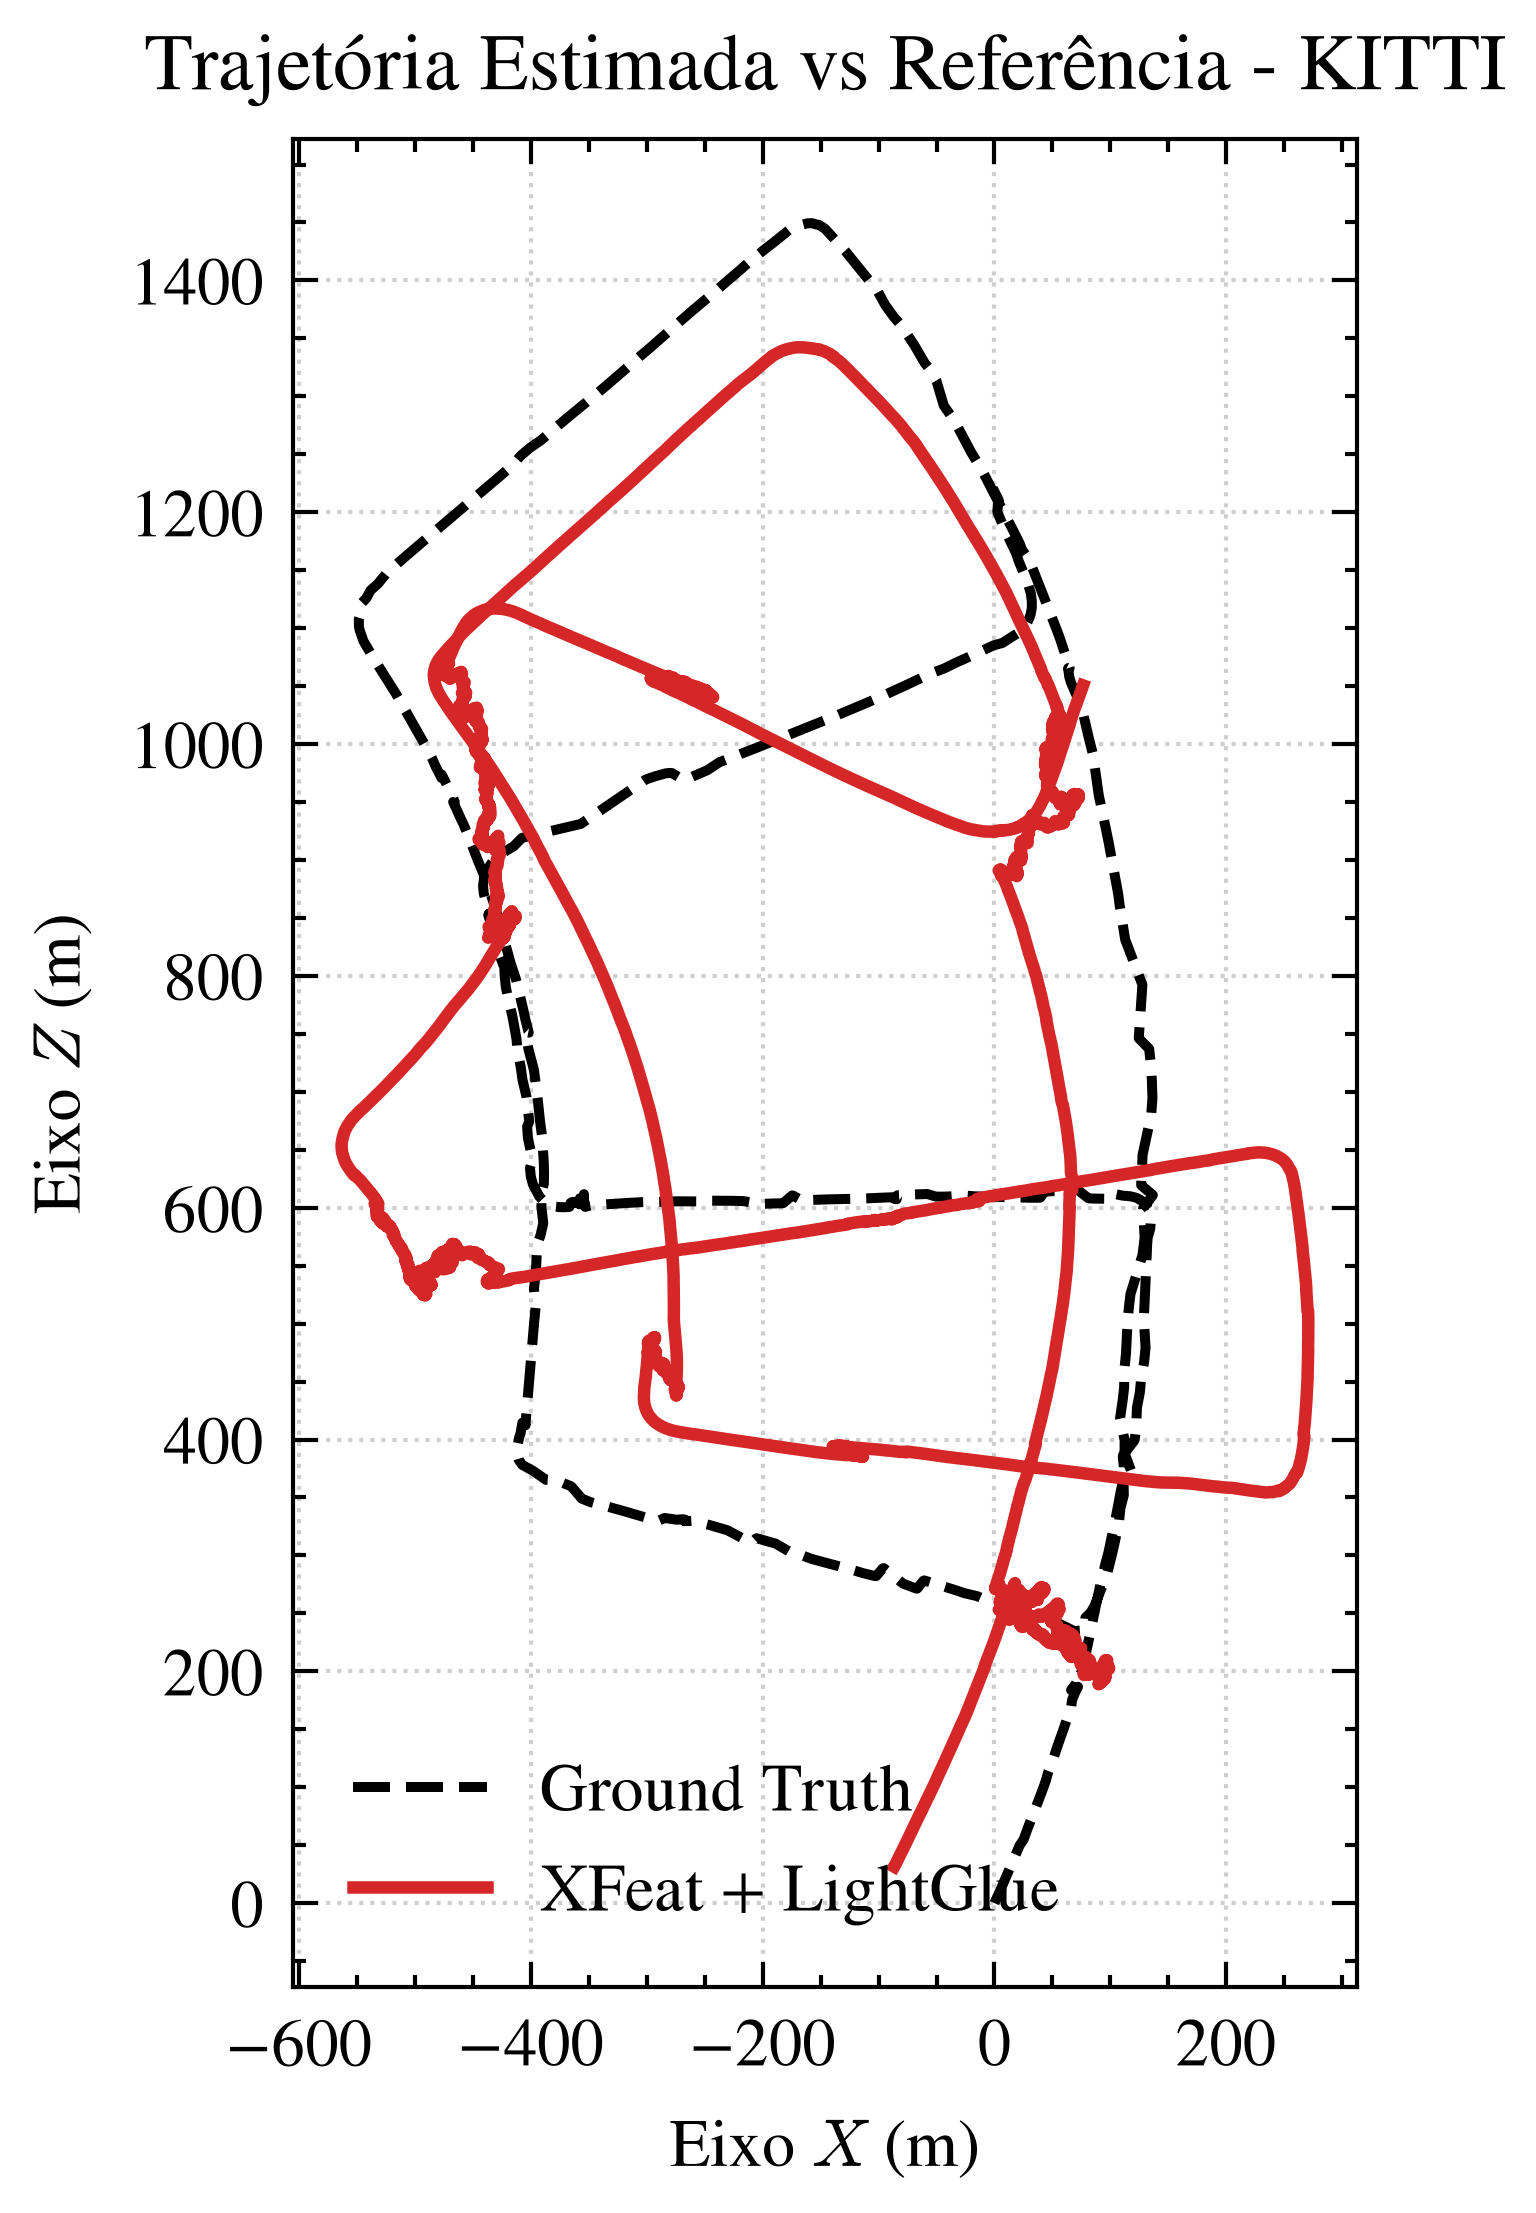

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots # Importa os estilos científicos

# Configura o estilo do gráfico para o padrão IEEE e habilita fontes LaTeX
plt.style.use(['science', 'ieee', 'no-latex'])
def ler_arquivo_tum(caminho_arquivo):
    """Lê um arquivo TUM e retorna as coordenadas X e Z (para robô planar)"""
    dados = np.loadtxt(caminho_arquivo)
    # Formato TUM: timestamp tx ty tz qx qy qz qw
    x = dados[:, 1]
    z = dados[:, 3] # Utilizando o eixo Z como profundidade, conforme seu modelo
    return x, z

# Carrega os dados alinhados (ajuste os nomes conforme os arquivos extraídos do zip do evo)
ref_x, ref_z = ler_arquivo_tum('/home/aki/Desktop/GitHub/Python-VO/urban30_gt_SIFT_FLANN_nopnp.tum')
est_x, est_z = ler_arquivo_tum('/home/aki/Desktop/GitHub/Python-VO/urban30_vo_SIFT_FLANN_nopnp.tum')

# Criação da figura
fig, ax = plt.subplots(figsize=(5, 4)) # Tamanho ideal para uma coluna de texto

# Plota o Ground Truth (linha tracejada, cor neutra)
ax.plot(ref_x, ref_z, label='Ground Truth', color='black', linestyle='--', linewidth=1.2)

# Plota a Estimativa (linha contínua, cor de destaque)
ax.plot(est_x, est_z, label='XFeat + LightGlue', color='#D62728', linewidth=1.5)

# Configurações de eixos e rótulos
ax.set_xlabel('Eixo $X$ (m)')
ax.set_ylabel('Eixo $Z$ (m)')
ax.set_title('Trajetória Estimada vs Referência - KITTI')

# Ajusta a proporção para 1:1 (para curvas e quadrados não ficarem distorcidos)
ax.set_aspect('equal', adjustable='box')

# Adiciona grade e legenda
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best')

# Salva em formato vetorizado (PDF) para não perder qualidade
plt.savefig('resultado_trajetoria.pdf', format='pdf', bbox_inches='tight')
plt.show()

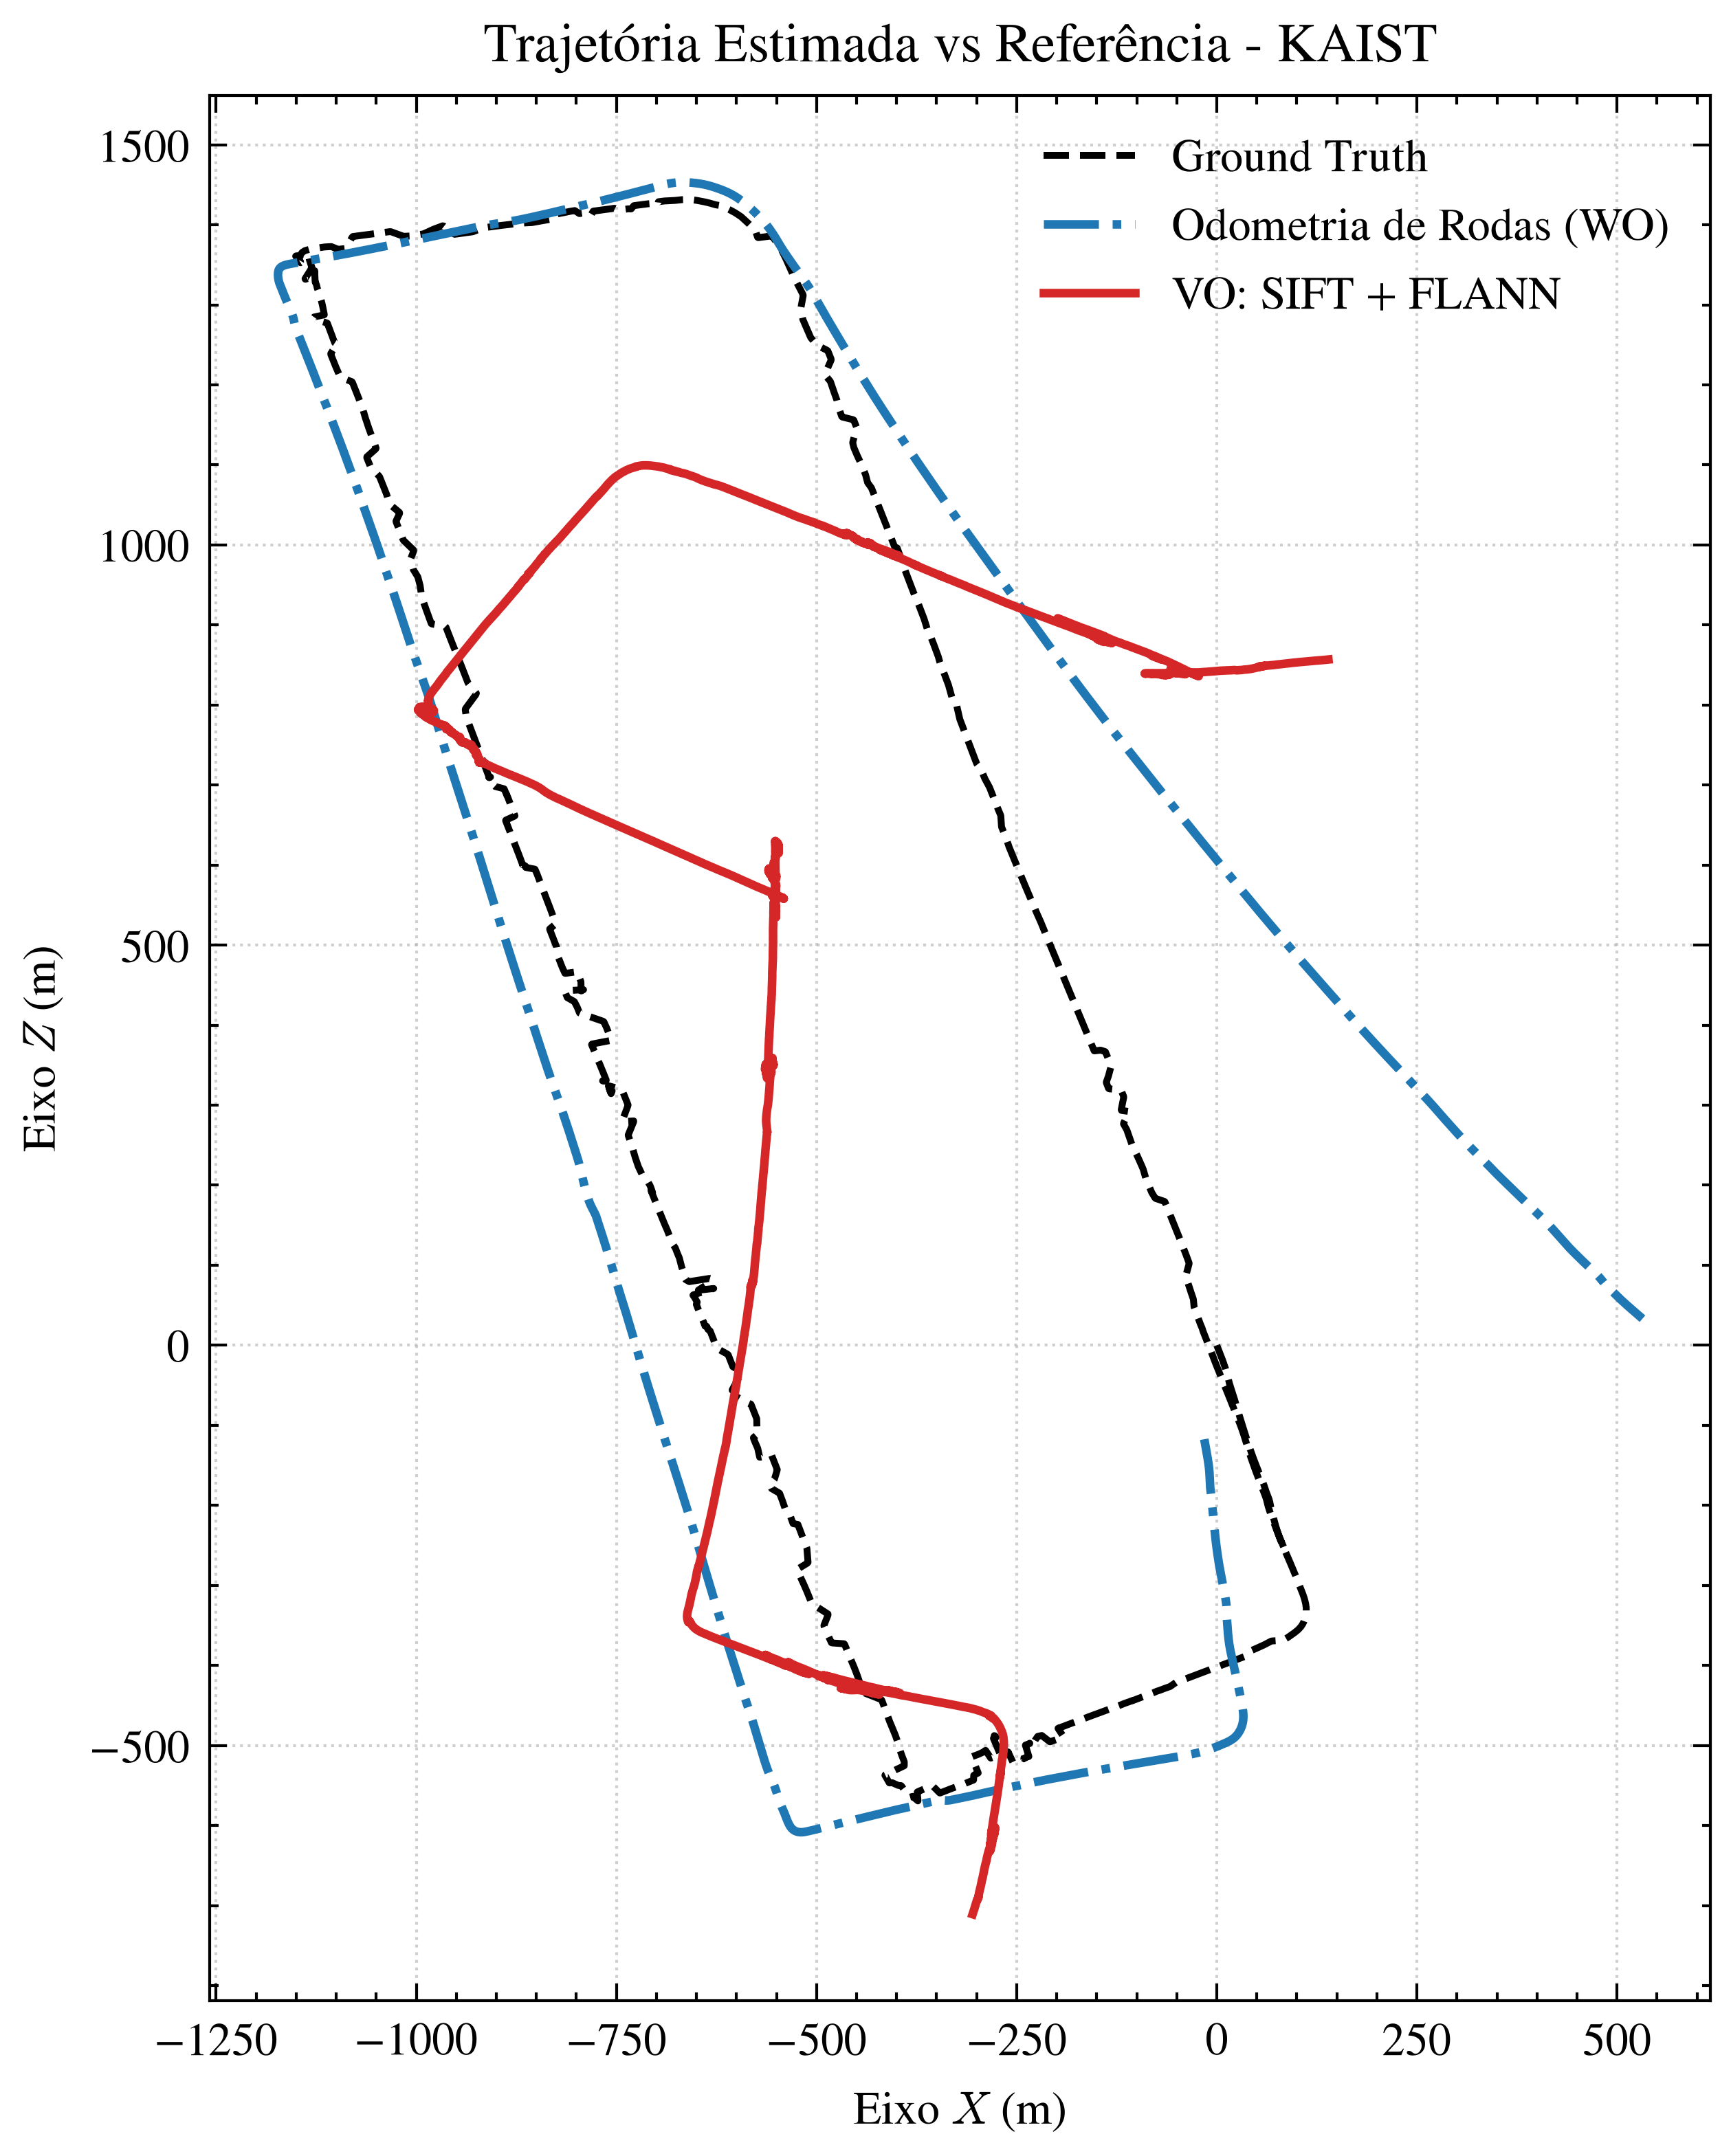

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots # Importa os estilos científicos

# Configura o estilo do gráfico para o padrão IEEE e habilita fontes LaTeX
plt.style.use(['science', 'ieee', 'no-latex'])

def ler_arquivo_tum(caminho_arquivo):
    """Lê um arquivo TUM e retorna as coordenadas X e Z (para robô planar)"""
    dados = np.loadtxt(caminho_arquivo)
    # Formato TUM: timestamp tx ty tz qx qy qz qw
    x = dados[:, 1]
    z = dados[:, 3] # Utilizando o eixo Z como profundidade, conforme seu modelo
    return x, z

# Carrega os dados alinhados (ajuste os nomes conforme os arquivos extraídos do zip do evo)
ref_x, ref_z = ler_arquivo_tum('/home/aki/Desktop/GitHub/Python-VO/urban30_gt_SUPERPOINT_FLANN_nopnp.tum')
est_x, est_z = ler_arquivo_tum('/home/aki/Desktop/GitHub/Python-VO/urban30_vo_SIFT_FLANN_nopnp.tum')

# NOVO: Carrega os dados da Odometria de Rodas (Ajuste o caminho do seu arquivo TUM gerado pelo evo)
wo_x, wo_z = ler_arquivo_tum('/home/aki/Desktop/GitHub/Python-VO/urban30_wo_ORB_KNN_nopnp.tum')

# Criação da figura
fig, ax = plt.subplots(figsize=(6, 6)) # Tamanho ideal para uma coluna de texto

# Plota o Ground Truth (linha tracejada, preta)
ax.plot(ref_x, ref_z, label='Ground Truth', color='black', linestyle='--', linewidth=1.2)

# NOVO: Plota a Odometria de Rodas (linha traço-ponto, azul)
ax.plot(wo_x, wo_z, label='Odometria de Rodas (WO)', color='#1F77B4', linestyle='-.', linewidth=1.5)

# Plota a Estimativa VO (linha contínua, cor de destaque vermelha)
ax.plot(est_x, est_z, label='VO: SIFT + FLANN', color='#D62728', linewidth=1.5)

# Configurações de eixos e rótulos
ax.set_xlabel('Eixo $X$ (m)')
ax.set_ylabel('Eixo $Z$ (m)')
ax.set_title('Trajetória Estimada vs Referência - KAIST')

# Ajusta a proporção para 1:1 (para curvas e quadrados não ficarem distorcidos)
ax.set_aspect('equal', adjustable='box')

# Adiciona grade e legenda
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best', fontsize=8) # Ajustado o tamanho da fonte para acomodar os 3 itens sem poluir

# Salva em formato vetorizado (PDF) para não perder qualidade
plt.savefig('resultado_trajetoria.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

plt.style.use(['science', 'ieee', 'no-latex'])

def ler_arquivo_tum(caminho_arquivo):
    dados = np.loadtxt(caminho_arquivo)
    x = dados[:, 1]
    z = dados[:, 3] 
    return x, z

# Carrega os dados (certifique-se de que os arquivos foram alinhados e sincronizados pelo evo)
ref_x, ref_z = ler_arquivo_tum('/home/aki/Desktop/GitHub/Python-VO/cusco_dataset_1_gt_XFEAT_LIGHT_nopnp.tum')
est_x, est_z = ler_arquivo_tum('/home/aki/Desktop/GitHub/Python-VO/cusco_dataset_1_vo_XFEAT_LIGHT_nopnp.tum')
wo_x, wo_z = ler_arquivo_tum('/home/aki/Desktop/GitHub/Python-VO/cusco_dataset_1_wo_alinhado.tum')

fig, ax = plt.subplots(figsize=(5, 4))

# Plota Ground Truth e Wheel Odometry
ax.plot(ref_x, ref_z, label='Ground Truth', color='black', linestyle='--', linewidth=1.2)
ax.plot(wo_x, wo_z, label='Odometria de Rodas', color='#1F77B4', linestyle='-.', linewidth=1.5)

# --- NOVO: Cálculo do APE e Plotagem Colorida ---
# Assumindo que os arrays est_x e ref_x têm o mesmo tamanho (sincronizados)
# Calculamos a distância Euclidiana (Erro) no plano XZ
erro_ape = np.sqrt((ref_x - est_x)**2 + (ref_z - est_z)**2)

# Usamos um scatter plot com colormap para colorir a trajetória baseado no erro
scatter = ax.scatter(est_x, est_z, c=erro_ape, cmap='jet', s=4, zorder=3, label='VO: XFeat + LightGlue')

# Adiciona a barra de cores (Colorbar)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Erro Absoluto (m)', fontsize=8)
cbar.ax.tick_params(labelsize=8)
# ------------------------------------------------

ax.set_xlabel('Eixo $X$ (m)')
ax.set_ylabel('Eixo $Z$ (m)')
ax.set_title('Trajetória Estimada vs Referência - CuscoBot')
ax.set_aspect('equal', adjustable='box')

ax.grid(True, linestyle=':', alpha=0.6)

# Pega os handles originais e ajusta a legenda para ignorar a formatação de cor única do scatter
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='best', fontsize=8) 

plt.savefig('resultado_trajetoria_colorida.pdf', format='pdf', bbox_inches='tight')
plt.show()

FileNotFoundError: /home/aki/Desktop/GitHub/Python-VO/cusco_dataset_1_wo_alinhado.tum not found.